# Yuyao Personal EDA and Baseline Modeling

**Research question:** Can basic building characteristics predict `Weather Normalized Site EUI (kBtu/ft²)`?

This notebook continues from the shared-cleaned dataset and focuses on three stages:
1. Personal EDA for the target and selected features
2. Task-specific preprocessing decisions
3. Baseline regression modeling

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")

In [4]:
file_path = "NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv"

target = "Weather Normalized Site EUI (kBtu/ft²)"
features = [
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Number of Buildings",
    "Primary Property Type - Self Selected",
    "City",
]

df = pd.read_csv(file_path, usecols=lambda c: c in features + [target], low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (103259, 6)


,City,Primary Property Type - Self Selected,Year Built,Number of Buildings,Weather Normalized Site EUI (kBtu/ft²),Property GFA - Self-Reported (ft²)
0,Queens,Non-Refrigerated Warehouse,1930,1,10.6,51749.0
1,Bronx,Multifamily Housing,1960,1,58.5,52941.0
2,Far Rockaway,Mixed Use Property,1941,1,64.1,35196.0
3,New York,Multifamily Housing,1898,1,69.0,107234.0
4,Queens,Medical Office,1911,1,50.9,75191.0


## 1. Personal EDA

The personal EDA focuses only on the selected target and basic building characteristics used in this individual project.

In [7]:
eda_summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
    "nunique": df.nunique(dropna=True),
})

eda_summary

,dtype,missing_count,missing_rate,nunique
City,object,0,0.000000,386
Primary Property Type - Self Selected,object,0,0.000000,84
Year Built,int64,0,0.000000,204
Number of Buildings,int64,0,0.000000,99
Weather Normalized Site EUI (kBtu/ft²),float64,17240,0.166959,3919
Property GFA - Self-Reported (ft²),float64,0,0.000000,32596


In [9]:
target_series = df[target].dropna()

target_summary = pd.Series({
    "count": target_series.shape[0],
    "missing_rate": df[target].isna().mean(),
    "nonpositive_count": (target_series <= 0).sum(),
    "skew": target_series.skew(),
    "p99": target_series.quantile(0.99),
    "p999": target_series.quantile(0.999),
    "max": target_series.max(),
})

target_summary

count                8.601900e+04
missing_rate         1.669588e-01
nonpositive_count    2.160000e+02
skew                 4.037552e+01
p99                  4.122560e+02
p999                 2.597570e+06
max                  1.629255e+07
dtype: float64

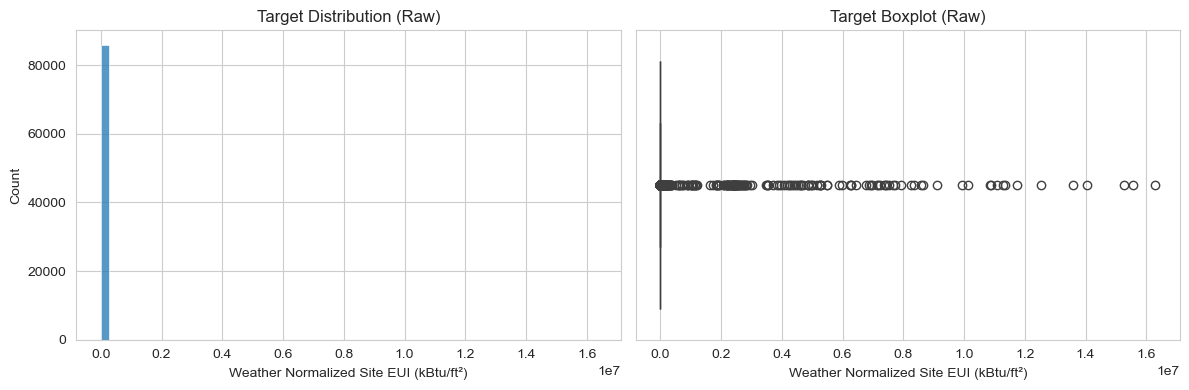

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(target_series, bins=60, ax=axes[0])
axes[0].set_title("Target Distribution (Raw)")
axes[0].set_xlabel(target)

sns.boxplot(x=target_series, ax=axes[1])
axes[1].set_title("Target Boxplot (Raw)")
axes[1].set_xlabel(target)

plt.tight_layout()
plt.show()

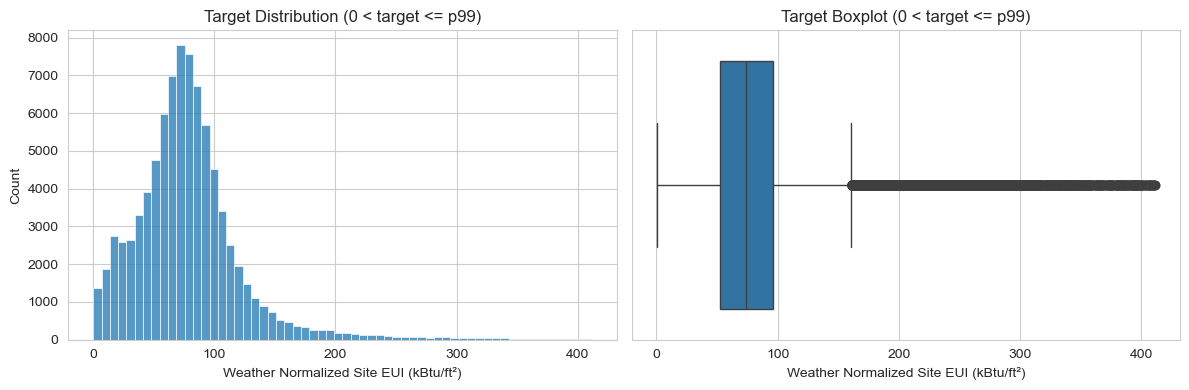

In [13]:
filtered_target = target_series[(target_series > 0) & (target_series <= target_series.quantile(0.99))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(filtered_target, bins=60, ax=axes[0])
axes[0].set_title("Target Distribution (0 < target <= p99)")
axes[0].set_xlabel(target)

sns.boxplot(x=filtered_target, ax=axes[1])
axes[1].set_title("Target Boxplot (0 < target <= p99)")
axes[1].set_xlabel(target)

plt.tight_layout()
plt.show()

In [15]:
numeric_features = ["Year Built", "Property GFA - Self-Reported (ft²)", "Number of Buildings"]
categorical_features = ["Primary Property Type - Self Selected", "City"]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Year Built,103259.0,1951.823434,34.843372,1051.0,1926.0,1949.0,1973.0,2088.0
Property GFA - Self-Reported (ft²),103259.0,121126.933305,304478.289583,0.0,34580.0,58765.0,112500.0,21150159.0
Number of Buildings,103259.0,1.348386,4.871286,0.0,1.0,1.0,1.0,514.0


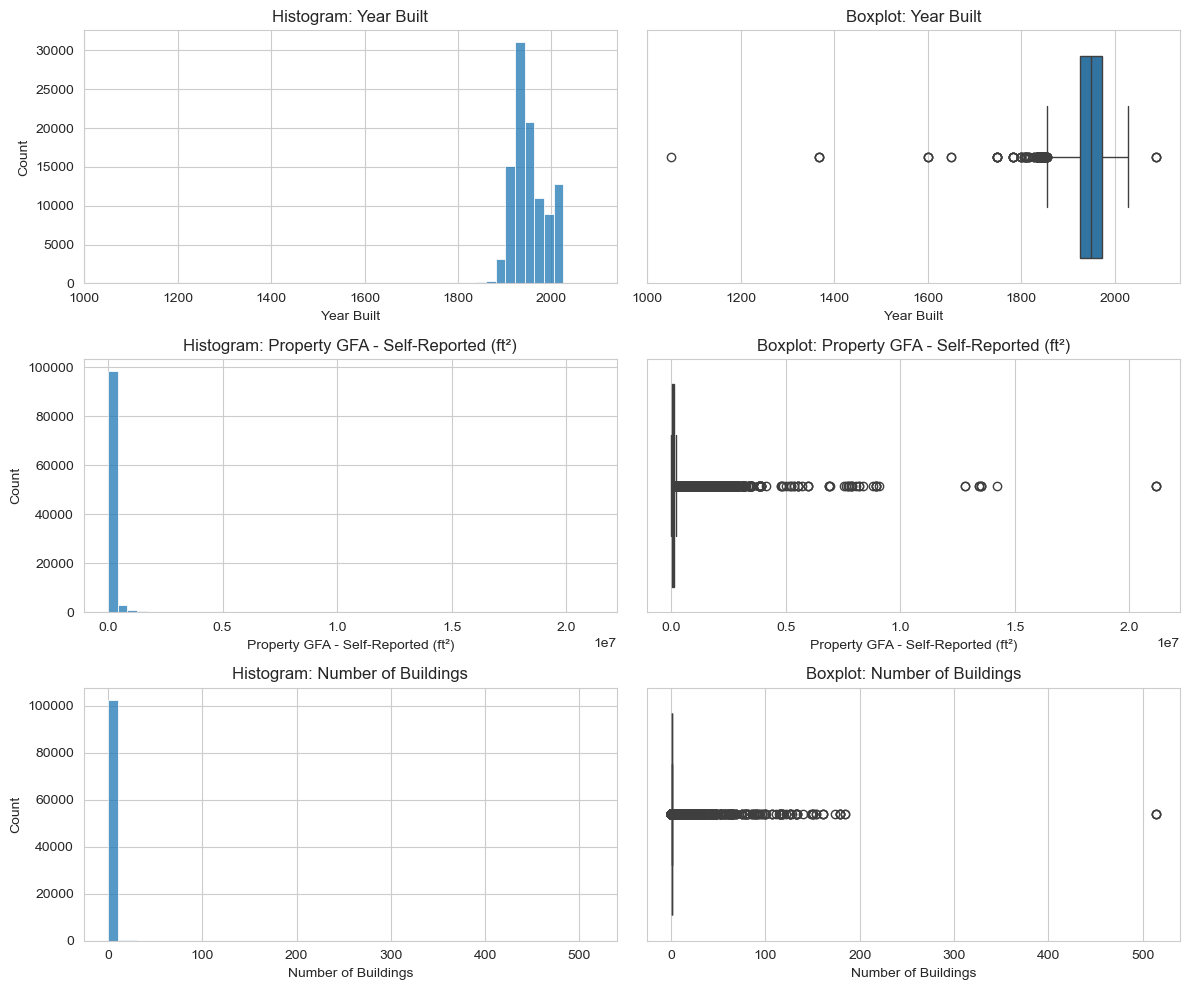

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for idx, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=50, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"Histogram: {col}")
    sns.boxplot(x=df[col], ax=axes[idx, 1])
    axes[idx, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

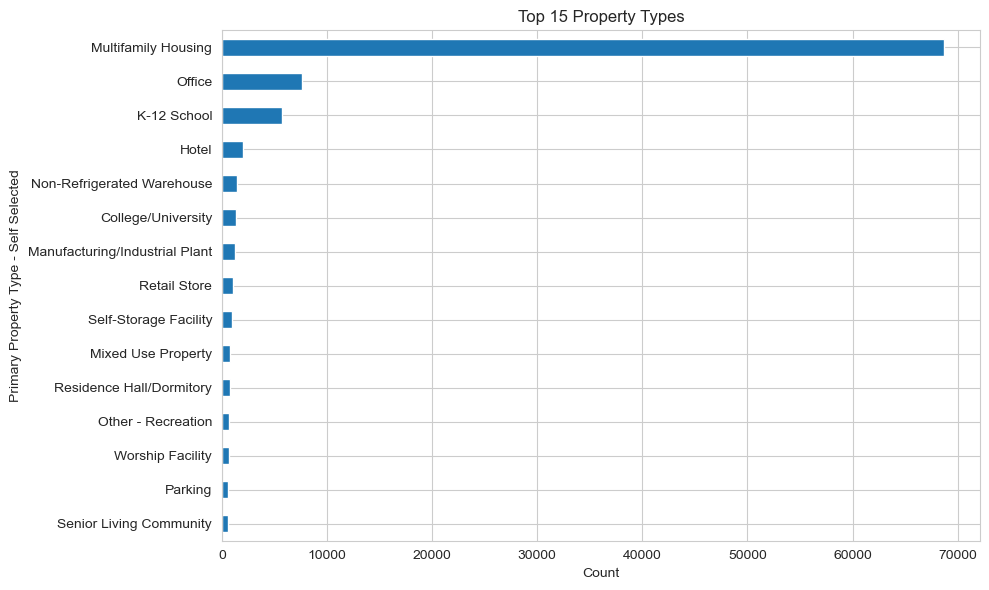

In [19]:
cat_col = "Primary Property Type - Self Selected"
plt.figure(figsize=(10, 6))
df[cat_col].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Property Types")
plt.xlabel("Count")
plt.ylabel(cat_col)
plt.tight_layout()
plt.show()

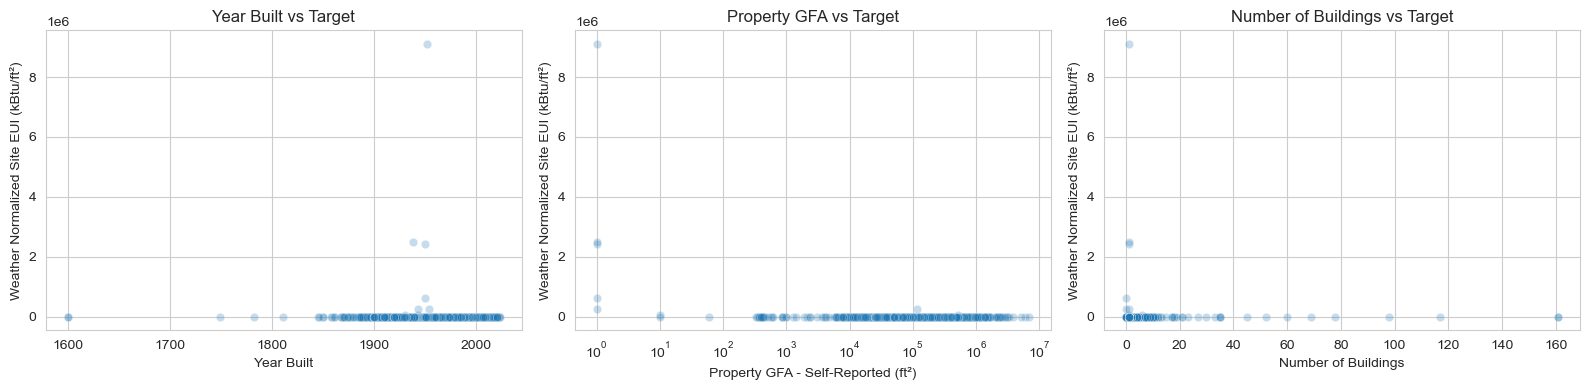

In [21]:
eda_df = df.dropna(subset=[target]).copy()
sample_df = eda_df.sample(min(5000, len(eda_df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=sample_df, x="Year Built", y=target, alpha=0.25, ax=axes[0])
axes[0].set_title("Year Built vs Target")

sns.scatterplot(data=sample_df, x="Property GFA - Self-Reported (ft²)", y=target, alpha=0.25, ax=axes[1])
axes[1].set_title("Property GFA vs Target")
axes[1].set_xscale("log")

sns.scatterplot(data=sample_df, x="Number of Buildings", y=target, alpha=0.25, ax=axes[2])
axes[2].set_title("Number of Buildings vs Target")

plt.tight_layout()
plt.show()

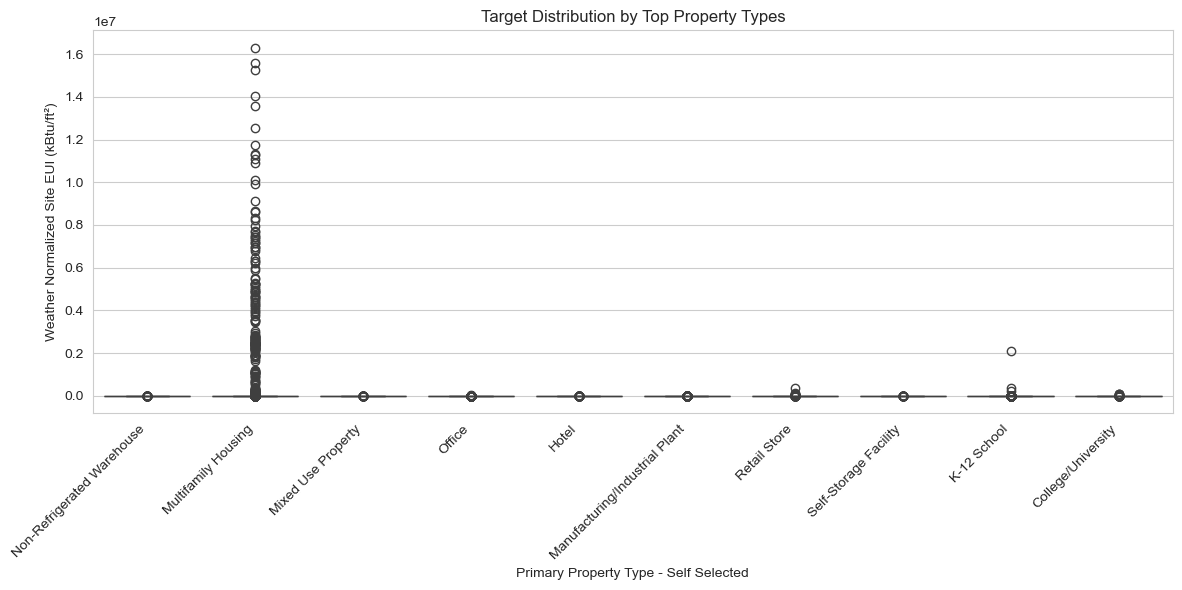

In [23]:
top_types = df[cat_col].value_counts().head(10).index
box_df = eda_df[eda_df[cat_col].isin(top_types)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=box_df, x=cat_col, y=target)
plt.xticks(rotation=45, ha="right")
plt.title("Target Distribution by Top Property Types")
plt.tight_layout()
plt.show()

**Initial EDA takeaway:** The target is heavily right-skewed and contains a small number of extreme values. For baseline modeling, a task-specific filtered subset is used to remove missing targets, exclude nonpositive values, and cap the target at the 99th percentile. This keeps the first baseline comparison more stable and interpretable.

## 2. Preprocessing Setup

In [32]:
model_df = df.dropna(subset=[target]).copy()
p99 = model_df[target].quantile(0.99)
model_df = model_df[(model_df[target] > 0) & (model_df[target] <= p99)].copy()

print("Modeling rows:", len(model_df))
print("Target upper threshold (p99):", round(p99, 3))
print("Target skew after filtering:", round(model_df[target].skew(), 3))

Modeling rows: 84942
Target upper threshold (p99): 412.256
Target skew after filtering: 1.99


In [34]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 3. Baseline Models

In [37]:
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
        "R2": r2_score(y_test, predictions),
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
3,RandomForestRegressor,20.178294,33.330645,0.489980
1,LinearRegression,31.153752,46.409778,0.011177
2,Ridge,31.153752,46.409778,0.011177
0,DummyRegressor,31.533513,46.683454,-0.000519


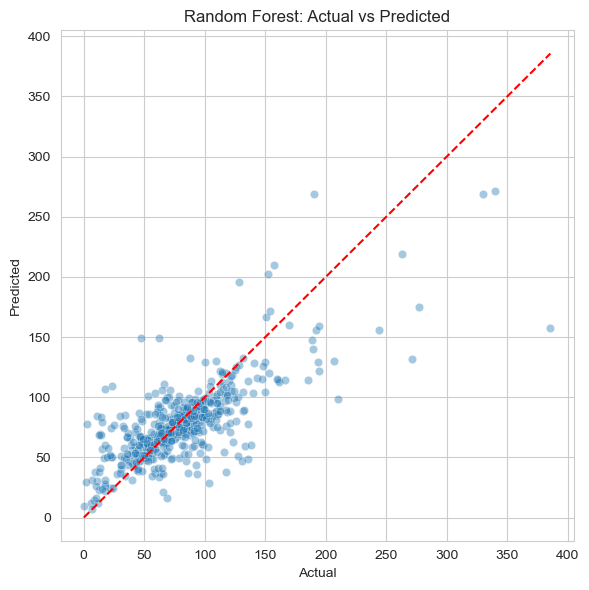

In [39]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    )),
])

best_model.fit(X_train, y_train)
rf_predictions = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "actual": y_test,
    "predicted": rf_predictions,
}).sample(min(500, len(y_test)), random_state=42)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=comparison_df, x="actual", y="predicted", alpha=0.4)
lims = [
    min(comparison_df["actual"].min(), comparison_df["predicted"].min()),
    max(comparison_df["actual"].max(), comparison_df["predicted"].max()),
]
plt.plot(lims, lims, color="red", linestyle="--")
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

## 4. Current Findings

1. The target variable is strongly skewed and contains a small number of extreme outliers.
2. A filtered modeling subset gives a more stable first baseline than using the raw target values directly.
3. In the initial comparison, the tree-based baseline is expected to outperform simple linear baselines because the relationship between building attributes and EUI is likely nonlinear.

## 5. Next Steps

1. Refine the feature set and consider whether a better location variable should replace or complement `City`.
2. Test alternative outlier-handling strategies and sensitivity checks.
3. Tune the tree-based model and compare it with regularized linear baselines more systematically.